In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

#### Carga de datos

In [2]:
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

Visualización general del dataset.

In [3]:
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

#### Examinación de estructura y contenido de variables.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Se observan muy pocos datos nulos en las columnas relacionadas a la bajada de los viajes. Se continúa con las métricas generales de las columnas numéricas.

In [5]:
df.describe()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


A través de este último cuadro, se comienzan a destacar datos atípicos relacionados a fare_amount y passanger_count. En el primer caso, se destacan valores negativos (cosa que se considera un error desde el comienzo por representar la tarifa final del viaje). En el segundo caso, se observa un viaje con 208 pasajeros. Se continúa visualizando dichos valores, más los valores nulos.

In [6]:
# Se imprimen los valores nulos
df[df.isna().any(axis=1)]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


**Visualización de valores atípicos.**

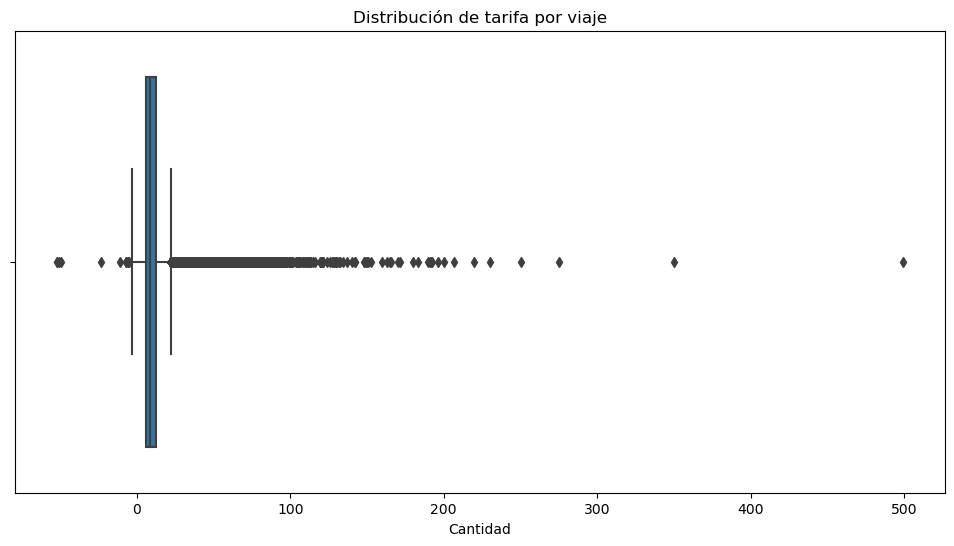

In [7]:
#Grafico para visualizar datos atípicos
# Distribución de tarifas totales por viaje
plt.figure(figsize=(12,6))
sns.boxplot(x=df['fare_amount'])
plt.title('Distribución de tarifa por viaje')
plt.xlabel('Cantidad')
plt.show()

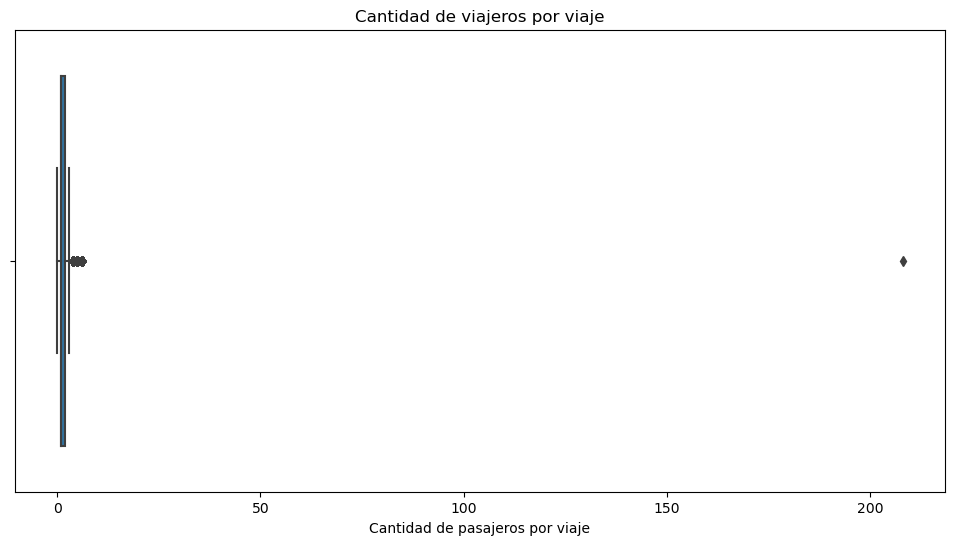

In [8]:
# Distribución de la cantidad de pasajeros por viaje (passenger_count)
plt.figure(figsize=(12,6))
sns.boxplot(x=df['passenger_count'])
plt.title('Cantidad de viajeros por viaje')
plt.xlabel('Cantidad de pasajeros por viaje')
plt.show()

El anterior análisis es verificado por los boxplots. Fare_amount posee varios valores negativos, lo cual es imposible ya que refiere a gastos hechos en viajes. Por otro lado, Passenger_count presenta como valor máximo (y atípico) una cantidad llamativa de 208 viajeros en un solo viaje. Se continúa con la observación de estos datos atípicos para luego imputarlos para los futuros modelos.

In [9]:
tarif_negat = df[df['fare_amount']<0]
len(tarif_negat)

17

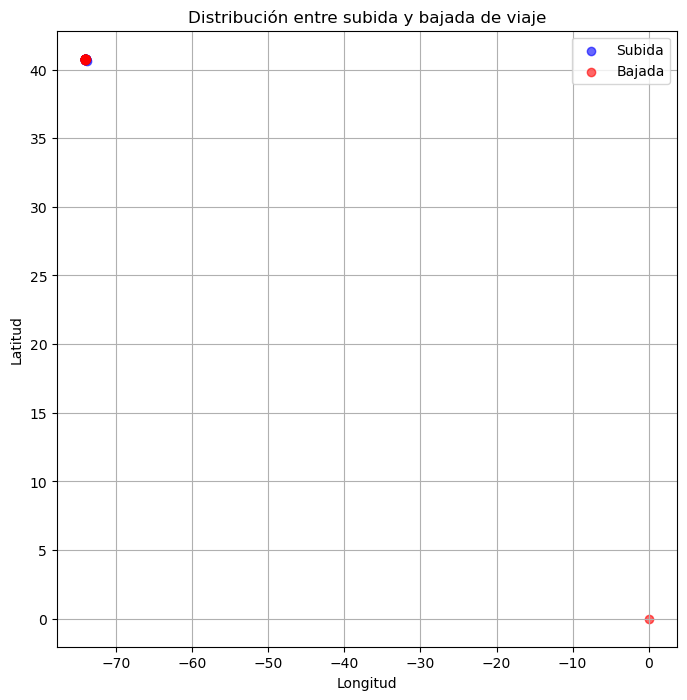

In [10]:
plt.figure(figsize=(8,8))
# Subida
plt.scatter(x=tarif_negat['pickup_longitude'], y=tarif_negat['pickup_latitude'],
            color='blue',
            label='Subida',
            alpha=0.6)

# Bajada
plt.scatter(x=tarif_negat['dropoff_longitude'], y=tarif_negat['dropoff_latitude'],
            color='red',
            label='Bajada',
            alpha=0.6)

plt.title('Distribución entre subida y bajada de viaje')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.legend()
plt.show()

Se puede teorizar, dados los resultados del scatterplot, que los 17 viajes con tarifas negativas, pudieron haber registrado algún error ya que se produjeron entre distancias demasiado cortas. Otra posible razón es que el GPRS del auto tuvo un error al registrar la distancia, lo que ocasionó el problema en la tarifa. **Se evaluará su método de imputación.**

In [11]:
#Se busca el valor atípico con más de 200 pasajeros
df[df['passenger_count']>=100]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
113038,35893772,2010-12-28 08:20:00.0000001,11.7,2010-12-28 08:20:00 UTC,-73.937795,40.758498,-73.937835,40.758415,208


In [12]:
#Se grafica para conocer la distribución sin dicho valor atípico
df_sin_atip_pass = df[df['passenger_count']<208]

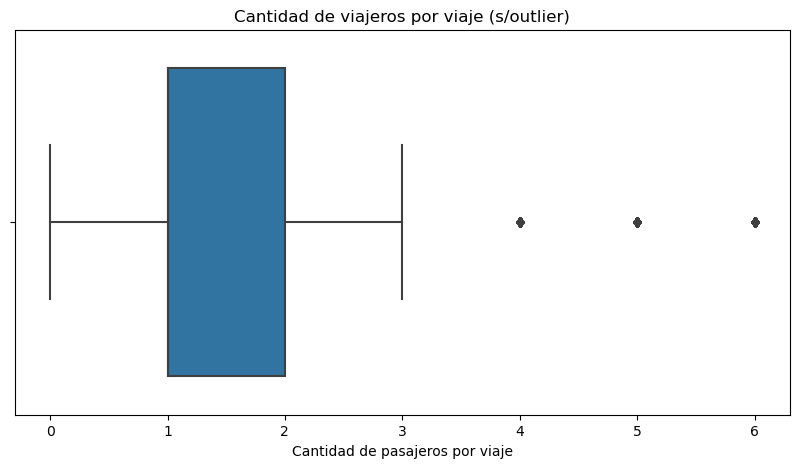

In [13]:
# Distribución passenger_count sin el outlier encontrado

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_sin_atip_pass['passenger_count'])
plt.title('Cantidad de viajeros por viaje (s/outlier)')
plt.xlabel('Cantidad de pasajeros por viaje')
plt.show()

Se puede teorizar que la cantidad 0 como cantidad de pasajeros pudo ser registrados de tal forma en los casos en los que se transportó paquetería. Su valor máximo es 3 y ahora los valores atípicos se consideran más normales al ser de 4, 5 y 6 (posibles dentro de un solo auto). **Se evaluará imputar el caso encontrado con el valor de la mediana**.

**Imputación de nulos**

In [14]:
df_limpio = df.copy()

In [15]:
# Se imputa el valor que tenía un nulo en bajadas ya que no ayudaría en el modelo predictivo
df_limpio = df_limpio.dropna()

In [16]:
# Se bien no hay valores con errores analizados previamente, se decide eliminar la columna 'date' 
# por ser tecnicamente igual a pickup_datetime
df_limpio[['date', 'pickup_datetime']].head()

,date,pickup_datetime
0,2015-05-07 19:52:06.0000003,2015-05-07 19:52:06 UTC
1,2009-07-17 20:04:56.0000002,2009-07-17 20:04:56 UTC
2,2009-08-24 21:45:00.00000061,2009-08-24 21:45:00 UTC
3,2009-06-26 08:22:21.0000001,2009-06-26 08:22:21 UTC
4,2014-08-28 17:47:00.000000188,2014-08-28 17:47:00 UTC


In [17]:
df_limpio = df_limpio.drop('date', axis=1)

In [18]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                199999 non-null  int64  
 1   fare_amount        199999 non-null  float64
 2   pickup_datetime    199999 non-null  object 
 3   pickup_longitude   199999 non-null  float64
 4   pickup_latitude    199999 non-null  float64
 5   dropoff_longitude  199999 non-null  float64
 6   dropoff_latitude   199999 non-null  float64
 7   passenger_count    199999 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 13.7+ MB


In [19]:
# Se observa que pickup_datetime no está en su formato necesario. Se modifica a datetime
df_limpio['pickup_datetime'] = pd.to_datetime(df_limpio['pickup_datetime'], utc=True)

In [20]:
# Se imputa el valor atípico de passenger_count por su mediana
df_limpio.loc[df_limpio['passenger_count'] == 208, 'passenger_count'] = df_limpio['passenger_count'].median()

Se grafican los histogramas de las variables modificadas y no modificadas, para chequear diferencias u otros detalles no captados previamente.

In [21]:
df_limpio_hist = df_limpio[['fare_amount','pickup_datetime','passenger_count','pickup_longitude','pickup_latitude',
'dropoff_longitude','dropoff_latitude']]

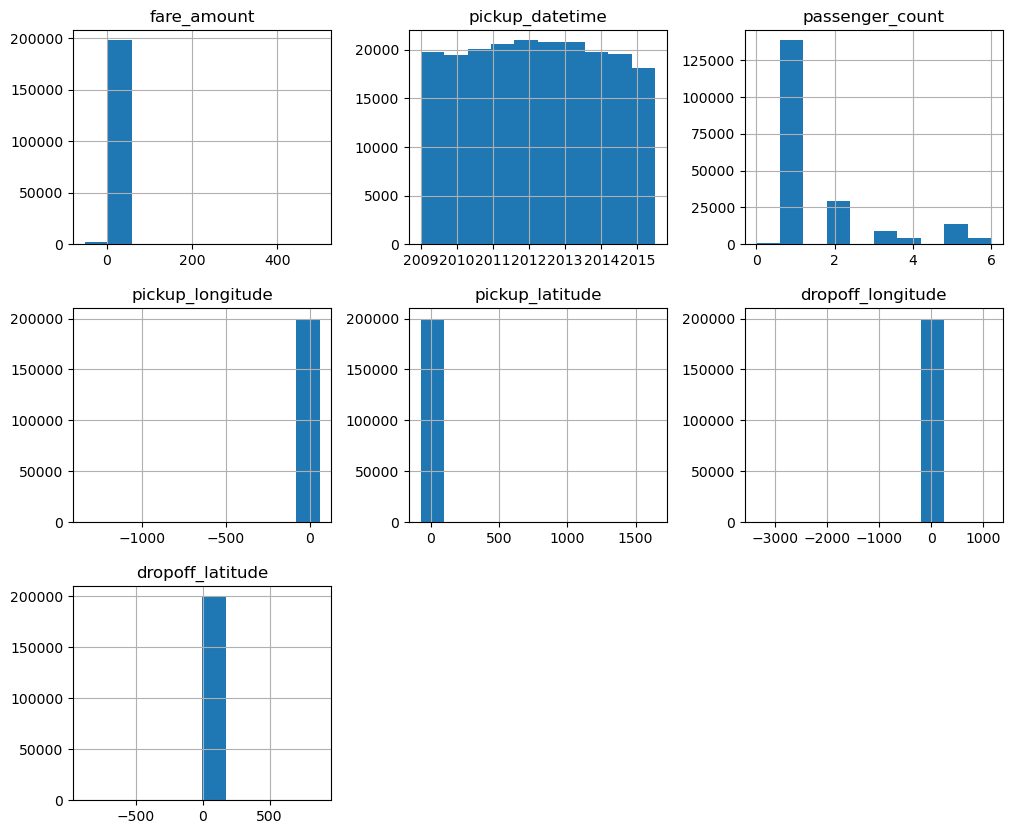

In [22]:
df_limpio_hist.hist(figsize=(12, 10))
plt.title('Distribuciones de variables potenciales para modelo')
plt.show()

Passenger_count y Pickup_datetime se consideran ya corregidas. Se procede a evaluar un poco más los longitudes y latitudes con relación a fare_amount para saber si sus valores atípicos tienen relación entre sí.

In [23]:
# Se crea una columna para conocer bien los KMs hechos por viaje
def manhattan_distance(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    # Convertir a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = np.abs(lat2 - lat1)
    dlon = np.abs(lon2 - lon1)

    # Distancia latitudinal
    a_lat = np.sin(dlat/2.0)**2
    c_lat = 2 * np.arcsin(np.sqrt(np.clip(a_lat, 0, 1)))
    dist_lat = R * c_lat

    # Distancia longitudinal (ajustada por latitudes)
    a_lon = np.sin(dlon/2.0)**2 * np.cos(lat1) * np.cos(lat2)
    c_lon = 2 * np.arcsin(np.sqrt(np.clip(a_lon, 0, 1)))
    dist_lon = R * c_lon

    return dist_lat + dist_lon

df_limpio['KMs'] = manhattan_distance(
    df_limpio['pickup_latitude'], df_limpio['pickup_longitude'],
    df_limpio['dropoff_latitude'], df_limpio['dropoff_longitude'])

In [48]:
df_limpio['KMs'].describe()

count    199999.000000
mean         27.052569
std         502.557605
min           0.000000
25%           1.549891
50%           2.720802
75%           4.993091
max       18829.539706
Name: KMs, dtype: float64

In [34]:
# Se guardan los valores con KMs = 0 para verificar más características
df_verif_kms = df_limpio[df_limpio['KMs'] == df_limpio['KMs'].min()]

In [ ]:
# No hay datos con KMs=0 con tarifas negativas -> No hay relación directa entre ellos
len(df_verif_kms[df_verif_kms['fare_amount']<0])

0

In [ ]:
# Cantidad de Kms=0 -> 5632, se debe decidir si se imputan o eliminan
len(df_verif_kms)

5632

In [50]:
df_limpio['fare_amount'].describe()

count    199999.000000
mean         11.359892
std           9.901760
min         -52.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

In [ ]:
# Las tarifas negativas recorrieron distancias cortas en su mayoría salvo los últimos datos
df_limpio[df_limpio['fare_amount']<0].sort_values(by='KMs')

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,KMs
89322,26673143,-49.57,2010-03-09 08:26:10+00:00,-73.972772,40.785657,-73.972867,40.785500,5,0.025456
150301,52122967,-3.00,2015-06-18 07:41:12+00:00,-74.004646,40.707355,-74.004013,40.707699,1,0.091552
179111,8191651,-3.50,2015-02-12 22:53:28+00:00,-73.989059,40.760181,-73.986649,40.761829,1,0.386297
63395,30260042,-5.00,2015-03-03 23:07:41+00:00,-73.992249,40.748936,-73.988518,40.748180,1,0.398264
79903,50284253,-3.50,2015-05-01 14:43:02+00:00,-73.982430,40.775024,-73.981750,40.778439,1,0.436812
98875,51135168,-52.00,2015-03-20 21:31:14+00:00,-74.000359,40.728729,-74.005699,40.728680,5,0.455534
180444,29504446,-3.00,2015-05-10 04:26:03+00:00,-73.983727,40.725910,-73.986099,40.722450,2,0.584678
71246,51325304,-3.30,2010-02-11 21:47:10+00:00,-73.952725,40.768235,-73.949928,40.772208,2,0.677318
157412,8135931,-3.50,2015-05-06 03:47:38+00:00,-73.986084,40.762146,-73.980476,40.759823,1,0.730614
190925,19185220,-5.50,2015-05-01 23:25:34+00:00,-73.988701,40.742649,-73.985924,40.735001,1,1.084446


In [ ]:
# Paralelamente, se sospecha que los valores máximos de las tarifas positivas pueden presentar errores
# Se presenta un viaje caro (casi 500 dólares) con muy poco recorrido
df_limpio[df_limpio['fare_amount'] == df_limpio['fare_amount'].max()]

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,KMs
170081,51151143,499.0,2011-04-10 04:10:00+00:00,-73.968377,40.764602,-73.968368,40.7646,1,0.00098


**RECORDATORIO: REVER KMS=0 y FARE_AMOUNT NEGATIVOS. NO PARECE HABER RELACIÓN DIRECTA ENTRE AMBOS**

Se agregan columnas relacionadas a días (y si el viaje se produjo un fin de semana) y horas (y si se produjo de noche o día), ya que se consideran valores importantes para el modelo predictivo buscado.

In [55]:
df_limpio['hour'] = df_limpio['pickup_datetime'].dt.hour
df_limpio['day'] = df_limpio['pickup_datetime'].dt.dayofweek   # 0=lunes, 6=domingo
df_limpio['is_weekend'] = df_limpio['day'] >= 5                # True si es viernes, sábado o domingo
df_limpio['is_night'] = (df_limpio['hour'] >= 22) | (df_limpio['hour'] < 6) # nocturno: 22 a 6

In [56]:
df_limpio.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,KMs,hour,day,is_weekend,is_night
0,24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.708841,19,3,False,False
1,27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.487317,20,4,False,False
2,44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,7.122435,21,0,False,False
3,25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2.300285,8,4,False,False
4,17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,5.956529,17,3,False,False


In [25]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='fare_amount'), df['fare_amount'], test_size=0.2, random_state=42)

In [26]:
X_train.describe()

,key,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.600000e+05,160000.000000,160000.000000,159999.000000,159999.000000,160000.000000
mean,2.771233e+07,-72.525896,39.936265,-72.525260,39.919258,1.684988
std,1.603218e+07,11.557753,8.090121,13.611271,6.880320,1.405686
min,1.000000e+00,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.379326e+07,-73.992062,40.734842,-73.991433,40.733835,1.000000
50%,2.775608e+07,-73.981834,40.752594,-73.980080,40.753044,1.000000
75%,4.155845e+07,-73.967212,40.767116,-73.963614,40.768055,2.000000
max,5.542357e+07,57.418457,1644.421482,1153.572603,872.697628,208.000000
